In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import scipy.io
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
import gc

# sc.settings.verbosity = 3
# sc.logging.print_versions()

### Analyze data

In [2]:
adata = sc.read('/local/home/am/EX_M/datasets/scRNA/retina/retina_preprocessed.h5ad')
adata

AnnData object with n_obs × n_vars = 51645 × 30698
    obs: 'biosample_id', 'donor_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type__custom', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'is_primary_data', 'age', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP'
    layers: 'counts'

In [3]:
adata.var

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,n_cells
ENSG00000243485,False,MIR1302-2HG,NCBITaxon:9606,gene,623,lncRNA,115
ENSG00000237613,False,FAM138A,NCBITaxon:9606,gene,888,lncRNA,17
ENSG00000238009,False,ENSG00000238009,NCBITaxon:9606,gene,629,lncRNA,258
ENSG00000241860,False,ENSG00000241860,NCBITaxon:9606,gene,1025,lncRNA,656
ENSG00000241599,False,ENSG00000241599,NCBITaxon:9606,gene,457,lncRNA,13
...,...,...,...,...,...,...,...
ENSG00000271254,False,ENSG00000271254,NCBITaxon:9606,gene,2922,protein_coding,832
ENSG00000276345,False,ENSG00000276345,NCBITaxon:9606,gene,740,protein_coding,11
ENSG00000278633,False,ENSG00000278633,NCBITaxon:9606,gene,2404,protein_coding,3
ENSG00000278817,False,ENSG00000278817,NCBITaxon:9606,gene,1213,protein_coding,861


/local/home/am/miniconda3/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/local/home/am/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


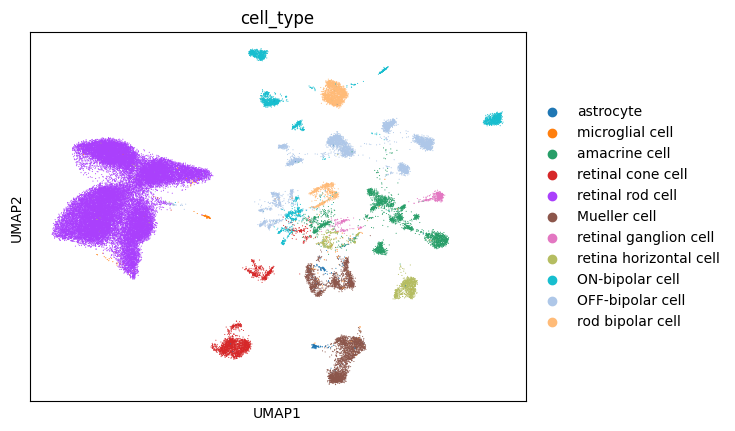

In [4]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], ncols=2)

In [5]:
train = sc.read('/local/home/am/EX_M/datasets/scRNA/retina/seed_32/scFoundation/train/retina_train_processed.h5ad')
train

/local/home/am/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 41288 × 19266
    obs: 'biosample_id', 'donor_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type__custom', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'is_primary_data', 'age', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [6]:
# find ratio of non-zero entries in train.X
(train.X > 0).sum() / (train.X.shape[0] * train.X.shape[1])

0.08017086626770789

In [7]:
print(((train.X > 0).sum(axis=1) >= 7000).sum())

train = train[train.obs[(train.X > 0).sum(axis=1) < 7000].index]
train

0


View of AnnData object with n_obs × n_vars = 41288 × 19266
    obs: 'biosample_id', 'donor_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type__custom', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'is_primary_data', 'age', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [10]:
# save the train data
train.write('/local/home/am/EX_M/datasets/scRNA/retina/seed_32/scFoundation/train/retina_train_processed.h5ad')

In [11]:
test = sc.read('/local/home/am/EX_M/datasets/scRNA/retina/seed_32/scFoundation/test/retina_test_processed.h5ad')
test

/local/home/am/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 5161 × 19266
    obs: 'biosample_id', 'donor_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type__custom', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'is_primary_data', 'age', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [12]:
print(((test.X > 0).sum(axis=1) >= 7000).sum())

test = test[test.obs[(test.X > 0).sum(axis=1) < 7000].index]
test

0


View of AnnData object with n_obs × n_vars = 5161 × 19266
    obs: 'biosample_id', 'donor_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type__custom', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'is_primary_data', 'age', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [13]:
# save the test data

test.write('/local/home/am/EX_M/datasets/scRNA/retina/seed_32/scFoundation/test/retina_test_processed.h5ad')

In [14]:
val = sc.read('/local/home/am/EX_M/datasets/scRNA/retina/seed_32/scFoundation/validation/retina_val_processed.h5ad')
val

/local/home/am/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 5158 × 19266
    obs: 'biosample_id', 'donor_id', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type__custom', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'is_primary_data', 'age', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'celltype', 'set', 'ID', 'label'
    uns: 'citation', 'hvg', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'

In [15]:
val = val[val.obs[(val.X > 0).sum(axis=1) < 7000].index]

In [16]:
# save the val data

val.write('/local/home/am/EX_M/datasets/scRNA/retina/seed_32/scFoundation/validation/retina_val_processed.h5ad')

In [17]:
train.obs['celltype'].value_counts()

celltype
retinal rod cell          25635
OFF-bipolar cell           3143
Mueller cell               2934
amacrine cell              2178
ON-bipolar cell            2094
rod bipolar cell           1859
retinal cone cell          1779
retina horizontal cell      907
retinal ganglion cell       391
astrocyte                   185
microglial cell             183
Name: count, dtype: int64

In [18]:
test.obs['celltype'].value_counts()

celltype
retinal rod cell          3206
OFF-bipolar cell           394
Mueller cell               368
amacrine cell              271
ON-bipolar cell            262
rod bipolar cell           232
retinal cone cell          222
retina horizontal cell     113
retinal ganglion cell       48
microglial cell             23
astrocyte                   22
Name: count, dtype: int64

In [19]:
val.obs['celltype'].value_counts()

celltype
retinal rod cell          3203
OFF-bipolar cell           392
Mueller cell               366
amacrine cell              273
ON-bipolar cell            261
rod bipolar cell           232
retinal cone cell          222
retina horizontal cell     115
retinal ganglion cell       46
microglial cell             24
astrocyte                   24
Name: count, dtype: int64